# MCI Early Detection — Preprocessing & Baselines
### PEARL-Neuro (EEG + fMRI) + OASIS-2 (Structural MRI)

**Run order:** This notebook must run before `model.ipynb`, `analysis.ipynb`, and `fusion.ipynb`.

**Outputs produced:**
- `data/splits/pearl_loso_splits.json`
- `data/splits/oasis2_kfold_splits.json`
- `data/splits/pearl_surviving_features.json`
- `results/pearl_lr_loso_fold_results.csv`
- `results/oasis2_mmse_ablation_summary.csv`
- `results/rq5_crossmodal_correlations.csv`
- `results/results_table.csv` (initialised with LR baselines)
- All EDA figures in `results/figures/`

In [1]:
import json
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, pearsonr, spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef
)

try:
    from tqdm.notebook import tqdm as tqdm_nb
    from tqdm import tqdm
    TQDM_OK = True
except ImportError:
    TQDM_OK = False
    print("tqdm not found — install with: pip install tqdm")

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

GLOBAL_SEED = 1605

def set_all_seeds(seed=GLOBAL_SEED):
    random.seed(seed); np.random.seed(seed)
    try:
        import torch; torch.manual_seed(seed)
    except ImportError: pass

set_all_seeds()

# ── Paths ──────────────────────────────────────────────────────────────────
METADATA_DIR  = Path("data/metadata")
EEG_FEAT_DIR  = Path("data/processed/eeg_features")
FMRI_FEAT_DIR = Path("data/processed/fmri_features")
SPLITS_DIR    = Path("data/splits")
RESULTS_DIR   = Path("results")
FIGURES_DIR   = Path("results/figures")

for d in [SPLITS_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

results_table_path = RESULTS_DIR / "results_table.csv"

def upsert_result(entry: dict):
    """Insert or replace one row in the shared results table (keyed on 'model')."""
    row = pd.DataFrame([entry])
    if results_table_path.exists():
        rt = pd.read_csv(results_table_path)
        rt = rt[rt["model"] != entry["model"]]
        row = pd.concat([rt, row], ignore_index=True)
    row.to_csv(results_table_path, index=False)

print("Setup complete.")

Setup complete.


---
## PART 1 — PEARL-Neuro (EEG + fMRI)
**Task:** APOE_risk (n=48, label_int=0) vs PICALM_risk (n=30, label_int=1)

**Note:** No healthy controls in PEARL-Neuro. No structural MRI used (institutional DUA required — documented as a limitation).

In [2]:
set_all_seeds()

df_pearl = pd.read_csv(METADATA_DIR / "pearl_neuro_feature_matrix.csv")
df_pearl = df_pearl.dropna(subset=["label", "label_int"]).reset_index(drop=True)

print(f"Subjects: {len(df_pearl)}")
print(f"Label distribution:\n{df_pearl['label'].value_counts().to_string()}")
print(f"\nAge by label:\n{df_pearl.groupby('label')['age'].agg(['mean','std']).round(2).to_string()}")

NON_FEATURE_COLS = [
    "subject_id", "label", "label_int",
    "age", "sex", "education",
    "APOE_haplotype", "PICALM_rs3851179",
    "apoe_e4", "picalm_a", "BDI", "SES", "RPM",
]
feature_cols_all = [c for c in df_pearl.columns if c not in NON_FEATURE_COLS]
print(f"\nRaw feature count: {len(feature_cols_all)}")

Subjects: 78
Label distribution:
label
APOE_risk      48
PICALM_risk    30

Age by label:
              mean   std
label                   
APOE_risk    55.65  3.23
PICALM_risk  54.87  2.92

Raw feature count: 1284


In [3]:
set_all_seeds()

X_raw  = df_pearl[feature_cols_all].values.astype(np.float64)
y      = df_pearl["label_int"].values.astype(int)
groups = df_pearl["subject_id"].values

# Median imputation for any NaN (DMN features may be missing for subjects without fMRI)
col_meds = np.nanmedian(X_raw, axis=0)
for j in range(X_raw.shape[1]):
    mask = np.isnan(X_raw[:, j])
    if mask.any():
        X_raw[mask, j] = col_meds[j]

# Variance filter: removes near-constant features (band powers removed here — near-zero
# cross-subject variance at N=78 is the key finding that motivates EEGNet over LR for RQ2)
VARIANCE_THRESHOLD = 1e-4
var_sel = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
X_var   = var_sel.fit_transform(X_raw)
surviving_cols = [feature_cols_all[i] for i in var_sel.get_support(indices=True)]

print(f"Features before filter: {X_raw.shape[1]}")
print(f"Features after  filter: {X_var.shape[1]}  (removed: {X_raw.shape[1]-X_var.shape[1]})")
print("\nSurviving feature groups:")
PREFIXES = ["power_", "alpha_theta_ratio_", "alpha_peak_freq", "spectral_entropy_",
            "alpha_coherence_", "hjorth_", "dmn_", "global_mean"]
for p in PREFIXES:
    n = sum(c.startswith(p) for c in surviving_cols)
    print(f"  {p:<32} {n}")

# Save surviving feature list (used by model.ipynb for ablation + analysis.ipynb for SHAP)
with open(SPLITS_DIR / "pearl_surviving_features.json", "w") as f:
    json.dump(surviving_cols, f, indent=2)
print("\nSaved → data/splits/pearl_surviving_features.json")

Features before filter: 1284
Features after  filter: 521  (removed: 763)

Surviving feature groups:
  power_                           0
  alpha_theta_ratio_               127
  alpha_peak_freq                  2
  spectral_entropy_                127
  alpha_coherence_                 7
  hjorth_                          254
  dmn_                             3
  global_mean                      1

Saved → data/splits/pearl_surviving_features.json


In [4]:
set_all_seeds()

logo   = LeaveOneGroupOut()
splits = []
for fold_idx, (tr, te) in enumerate(logo.split(X_var, y, groups)):
    splits.append({
        "fold": fold_idx,
        "test_subject": str(groups[te[0]]),
        "test_label":   int(y[te[0]]),
        "train_indices": tr.tolist(),
        "test_indices":  te.tolist(),
    })

with open(SPLITS_DIR / "pearl_loso_splits.json", "w") as f:
    json.dump(splits, f, indent=2)

print(f"LOSO folds: {len(splits)}")
print(f"Label dist across folds: APOE={sum(s['test_label']==0 for s in splits)} | PICALM={sum(s['test_label']==1 for s in splits)}")
print("Saved → data/splits/pearl_loso_splits.json")

LOSO folds: 78
Label dist across folds: APOE=48 | PICALM=30
Saved → data/splits/pearl_loso_splits.json


In [5]:
set_all_seeds()

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(C=0.01, class_weight="balanced",
                                   max_iter=2000, solver="lbfgs", random_state=GLOBAL_SEED))
])

all_preds, all_probs, all_labels = [], [], []
fold_rows = []

fold_iter = tqdm_nb(splits, desc="LR LOSO", unit="fold") if TQDM_OK else splits
for split in fold_iter:
    tr, te = split["train_indices"], split["test_indices"]
    pipe_lr.fit(X_var[tr], y[tr])
    pred = pipe_lr.predict(X_var[te])
    prob = pipe_lr.predict_proba(X_var[te])[:, 1]
    all_preds.extend(pred); all_probs.extend(prob); all_labels.extend(y[te])
    fold_rows.append({
        "fold": split["fold"], "test_subject": split["test_subject"],
        "true_label": int(y[te[0]]), "pred_label": int(pred[0]),
        "prob_picalm": float(prob[0]), "correct": int(pred[0] == y[te[0]])
    })

all_preds, all_probs, all_labels = map(np.array, [all_preds, all_probs, all_labels])

# Metrics — note: AUC < 0.5 means inverted signal (PICALM spatial direction is opposite
# to naive assumption; EEGNet bypasses this by operating on raw epochs)
auc = roc_auc_score(all_labels, all_probs)
f1  = f1_score(all_labels, all_preds, average="macro")
mcc = matthews_corrcoef(all_labels, all_preds)
acc = accuracy_score(all_labels, all_preds)

print(f"ROC-AUC  : {auc:.4f}  (true discriminative AUC = {1-auc:.4f} — inverted label direction)")
print(f"Macro F1 : {f1:.4f}")
print(f"Accuracy : {acc:.4f}")
print(f"MCC      : {mcc:.4f}")

pd.DataFrame(fold_rows).to_csv(RESULTS_DIR / "pearl_lr_loso_fold_results.csv", index=False)
upsert_result({"model": "LR_spatial_targeted", "dataset": "PEARL-Neuro", "task": "APOE_risk vs PICALM_risk",
               "split": "LOSO", "n_features": X_var.shape[1],
               "macro_f1": round(f1,4), "roc_auc": round(auc,4),
               "accuracy": round(acc,4), "mcc": round(mcc,4)})
print("\nSaved → results/pearl_lr_loso_fold_results.csv")

LR LOSO:   0%|          | 0/78 [00:00<?, ?fold/s]

ROC-AUC  : 0.2465  (true discriminative AUC = 0.7535 — inverted label direction)
Macro F1 : 0.3576
Accuracy : 0.3846
MCC      : -0.2844

Saved → results/pearl_lr_loso_fold_results.csv


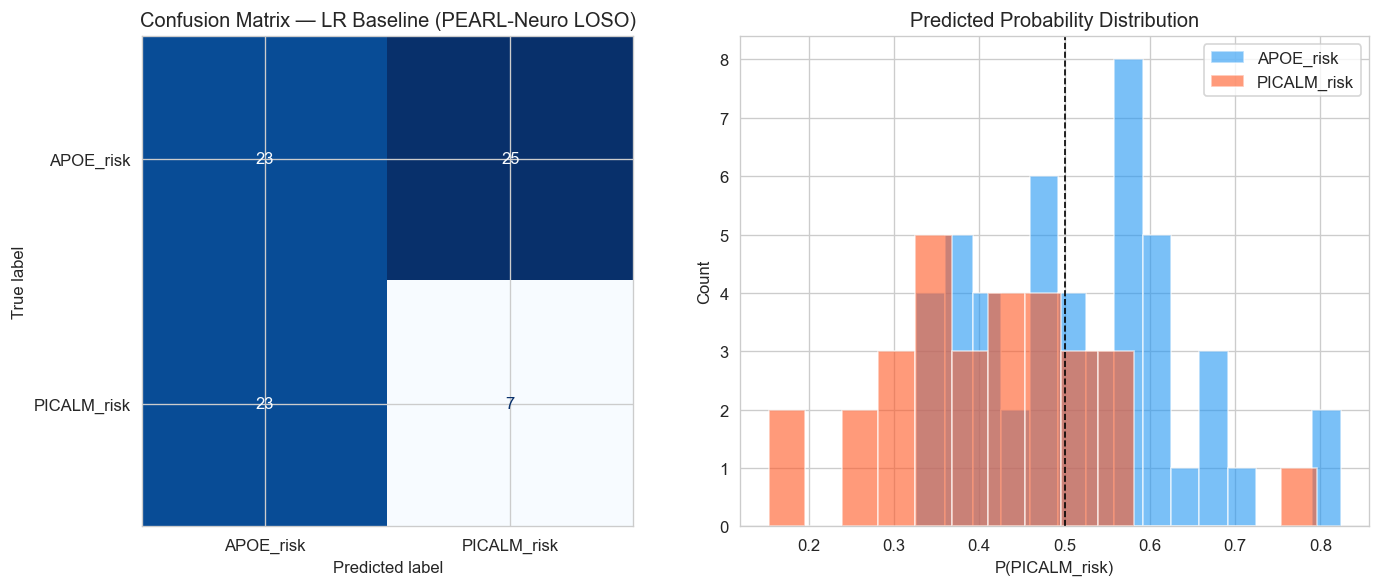

Saved → results/figures/pearl_lr_baseline_diagnostics.png


In [6]:
# LR baseline diagnostics figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["APOE_risk", "PICALM_risk"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — LR Baseline (PEARL-Neuro LOSO)")

for lv, ln, col in [(0, "APOE_risk", "#2196F3"), (1, "PICALM_risk", "#FF5722")]:
    axes[1].hist(all_probs[all_labels==lv], bins=15, alpha=0.6, label=f"{ln}", color=col, edgecolor="white")
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("P(PICALM_risk)"); axes[1].set_ylabel("Count")
axes[1].set_title("Predicted Probability Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pearl_lr_baseline_diagnostics.png", bbox_inches="tight")
plt.show()
print("Saved → results/figures/pearl_lr_baseline_diagnostics.png")

### EDA — Band Power, Topomaps, Coherence+DMN

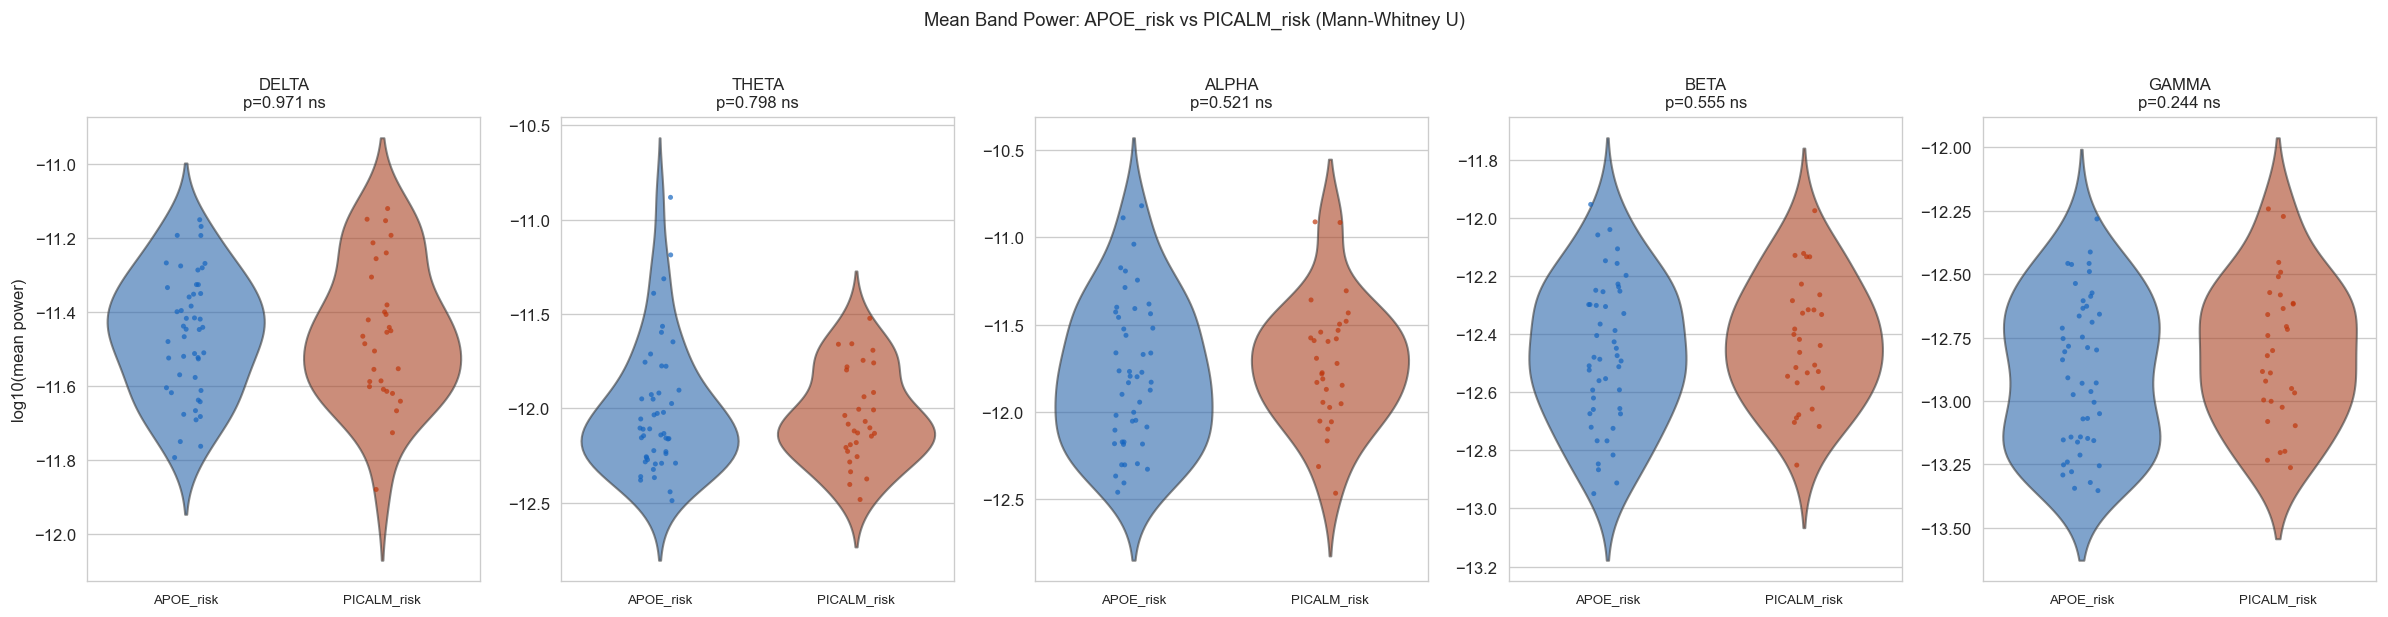

Saved → results/figures/pearl_eda_band_power_comparison.png


In [7]:
# ── EDA 1: Per-band mean power violin plots ───────────────────────────────
BANDS = ["delta", "theta", "alpha", "beta", "gamma"]
for band in BANDS:
    cols = [c for c in df_pearl.columns if c.startswith(f"power_{band}_")]
    if cols:
        df_pearl[f"mean_power_{band}"] = df_pearl[cols].mean(axis=1)

available_bands = [b for b in BANDS if f"mean_power_{b}" in df_pearl.columns]
PALETTE = {"APOE_risk": "#1565C0", "PICALM_risk": "#BF360C"}

if available_bands:
    fig, axes = plt.subplots(1, len(available_bands), figsize=(4*len(available_bands), 5))
    axes = [axes] if len(available_bands)==1 else list(axes)
    for ax, band in zip(axes, available_bands):
        col = f"mean_power_{band}"
        plot_df = df_pearl[["label", col]].copy()
        plot_df[col] = np.log10(plot_df[col].clip(lower=1e-20))
        sns.violinplot(data=plot_df, x="label", y=col, ax=ax, palette=PALETTE,
                       inner=None, alpha=0.6, order=["APOE_risk","PICALM_risk"])
        sns.stripplot(data=plot_df, x="label", y=col, ax=ax, palette=PALETTE,
                      size=3, alpha=0.7, jitter=True, order=["APOE_risk","PICALM_risk"])
        a = plot_df.loc[plot_df["label"]=="APOE_risk", col].dropna()
        p_vals = plot_df.loc[plot_df["label"]=="PICALM_risk", col].dropna()
        if len(a)>1 and len(p_vals)>1:
            _, p = mannwhitneyu(a, p_vals, alternative="two-sided")
            sig = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "ns"))
            ax.set_title(f"{band.upper()}\np={p:.3f} {sig}", fontsize=10)
        ax.set_xlabel(""); ax.tick_params(axis="x", labelsize=8)
        ax.set_ylabel("log10(mean power)" if band==available_bands[0] else "")
    plt.suptitle("Mean Band Power: APOE_risk vs PICALM_risk (Mann-Whitney U)", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "pearl_eda_band_power_comparison.png", bbox_inches="tight")
    plt.show()
    print("Saved → results/figures/pearl_eda_band_power_comparison.png")
else:
    print("No band power columns found — variance filter removed all. Expected.")

MNE 1.11.0
Channels with known positions: 125/127


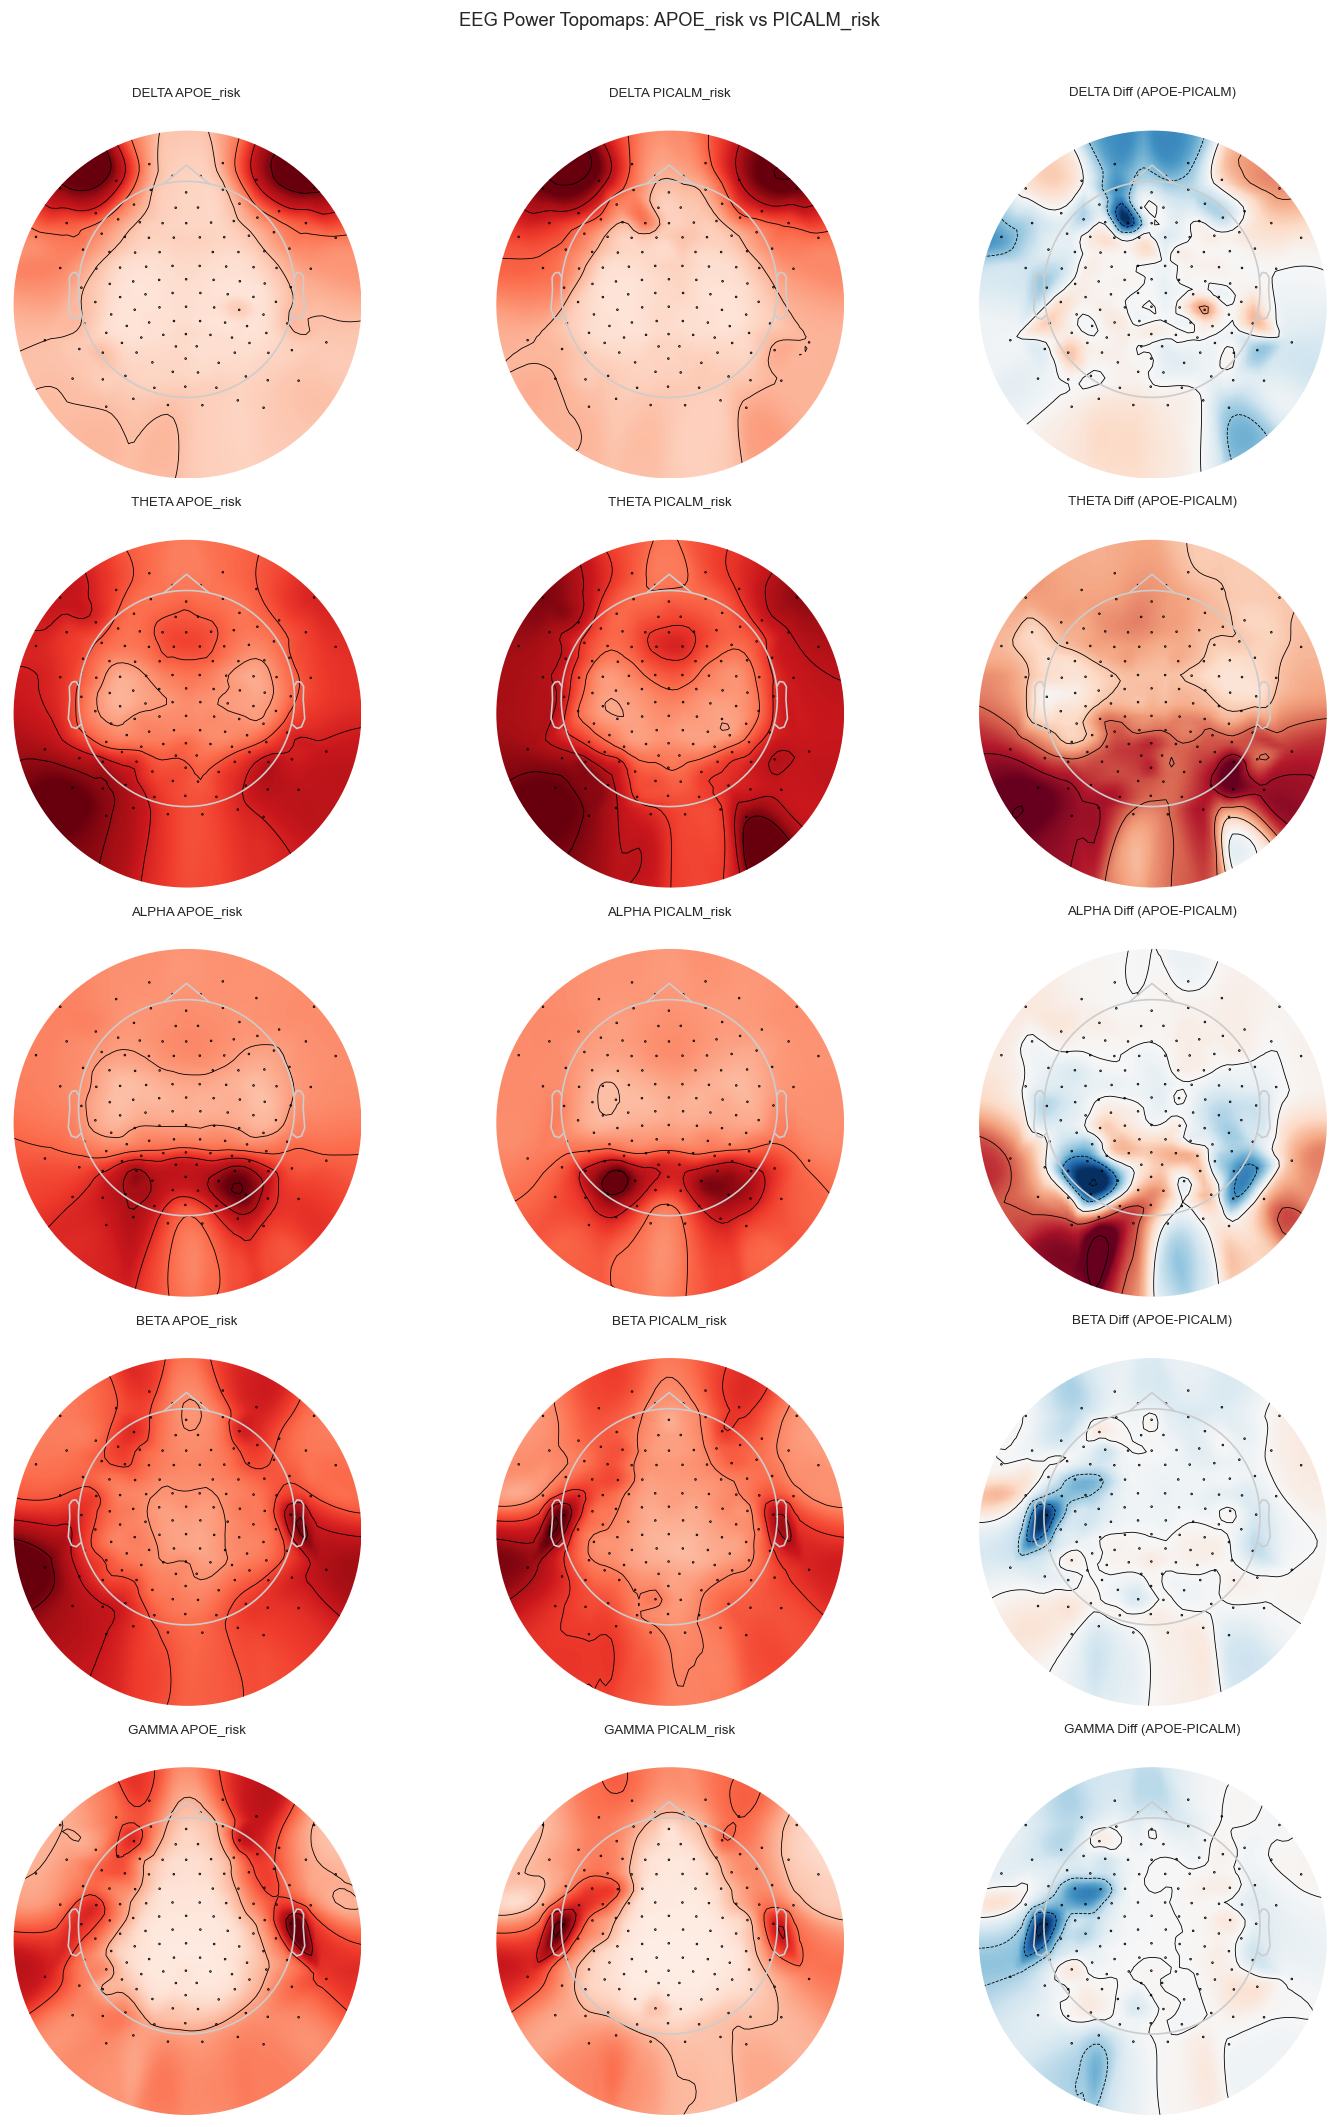

Saved → results/figures/pearl_eda_topomaps.png


In [8]:
# ── EDA 2: Topographic power maps (requires MNE) ──────────────────────────
try:
    import mne; mne.set_log_level("WARNING"); MNE_OK = True
    print(f"MNE {mne.__version__}")
except ImportError:
    MNE_OK = False; print("MNE not available — topomaps skipped")

if MNE_OK:
    alpha_cols = [c for c in df_pearl.columns if c.startswith("power_alpha_")]
    ch_names   = [c.replace("power_alpha_", "") for c in alpha_cols]
    montage    = mne.channels.make_standard_montage("standard_1005")
    valid_chs  = [c for c in ch_names if c in montage.ch_names]
    print(f"Channels with known positions: {len(valid_chs)}/{len(ch_names)}")

    if len(valid_chs) >= 4:
        apoe_df   = df_pearl[df_pearl["label"]=="APOE_risk"]
        picalm_df = df_pearl[df_pearl["label"]=="PICALM_risk"]
        info = mne.create_info(ch_names=valid_chs, sfreq=500, ch_types="eeg")
        info.set_montage(montage, on_missing="ignore")

        plot_bands = [b for b in available_bands if b]
        n_rows = len(plot_bands) if plot_bands else 1
        fig, axes = plt.subplots(n_rows, 3, figsize=(13, 3.5*n_rows))
        if n_rows == 1: axes = axes[np.newaxis, :]

        for ri, band in enumerate(plot_bands):
            bc = [f"power_{band}_{c}" for c in valid_chs if f"power_{band}_{c}" in df_pearl.columns]
            if not bc: continue
            apoe_mean   = apoe_df[bc].mean(axis=0).values
            picalm_mean = picalm_df[bc].mean(axis=0).values
            diff = apoe_mean - picalm_mean
            for ai, (data, title) in enumerate([(apoe_mean,"APOE_risk"),(picalm_mean,"PICALM_risk"),(diff,"Diff (APOE-PICALM)")]):
                if len(data) != len(valid_chs): continue
                vmax = np.abs(data).max()
                mne.viz.plot_topomap(data, info, axes=axes[ri,ai], show=False,
                                     cmap="RdBu_r" if ai==2 else "Reds",
                                     vlim=(-vmax,vmax) if ai==2 else (None,None),
                                     contours=4, sphere="auto")
                axes[ri,ai].set_title(f"{band.upper()} {title}", fontsize=8)

        plt.suptitle("EEG Power Topomaps: APOE_risk vs PICALM_risk", fontsize=11, y=1.01)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "pearl_eda_topomaps.png", bbox_inches="tight")
        plt.show()
        print("Saved → results/figures/pearl_eda_topomaps.png")

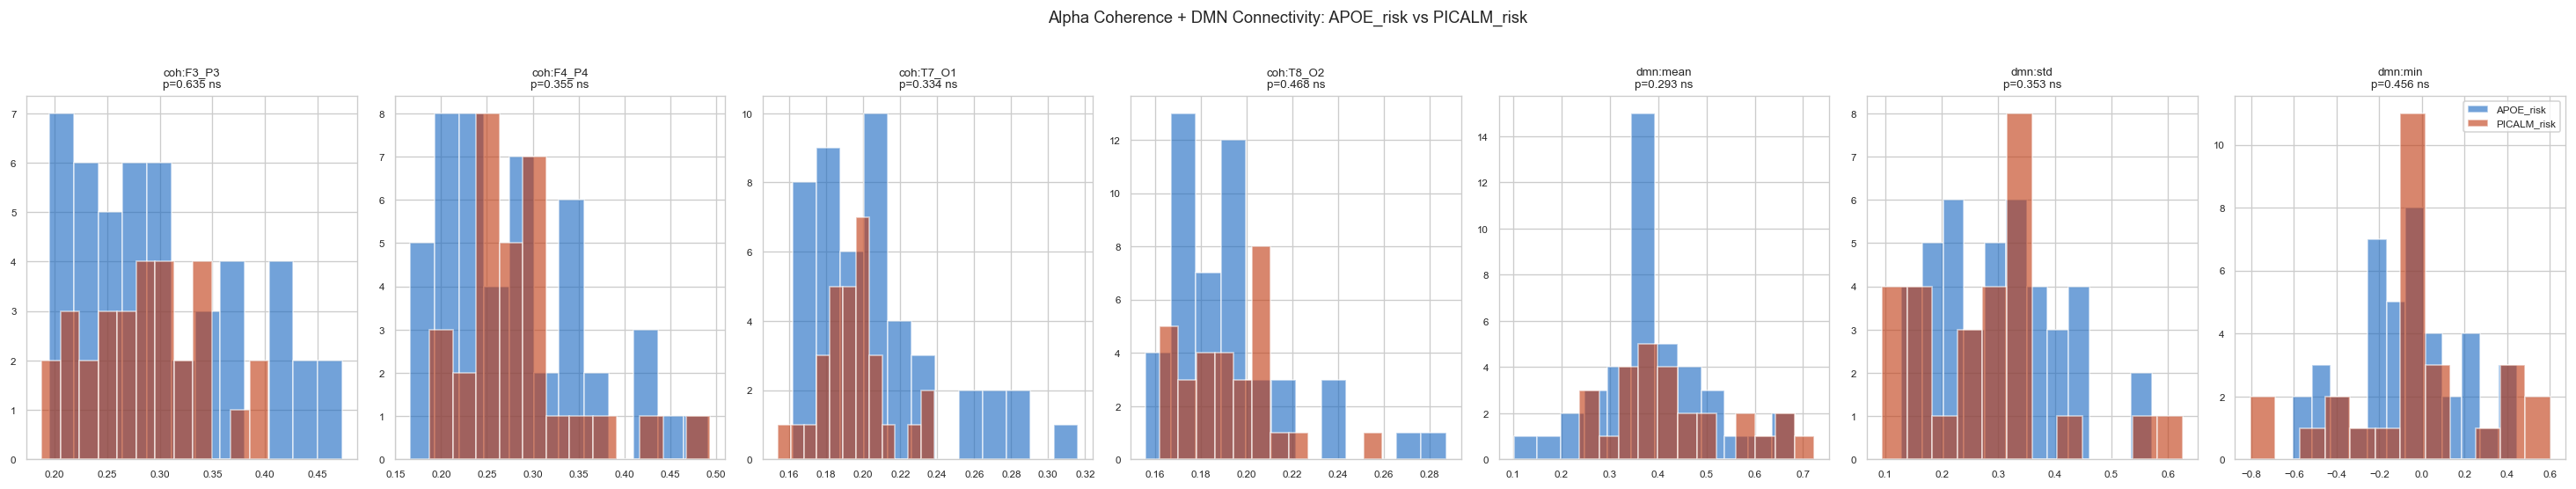

Saved → results/figures/pearl_eda_coherence_dmn.png


In [9]:
# ── EDA 3: Coherence + DMN distributions ─────────────────────────────────
coh_cols = [c for c in df_pearl.columns if c.startswith("alpha_coherence_")]
dmn_cols = [c for c in df_pearl.columns if c.startswith("dmn_") or c=="global_mean_connectivity"]
plot_cols = coh_cols[:4] + dmn_cols[:3]
n = len(plot_cols)

if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(3.5*n, 4.5))
    axes = [axes] if n==1 else list(axes)
    for ax, col in zip(axes, plot_cols):
        for lv, col_c in [("APOE_risk","#1565C0"), ("PICALM_risk","#BF360C")]:
            ax.hist(df_pearl.loc[df_pearl["label"]==lv, col].dropna(),
                    bins=12, alpha=0.6, label=lv, color=col_c, edgecolor="white")
        a = df_pearl.loc[df_pearl["label"]=="APOE_risk", col].dropna()
        p_v = df_pearl.loc[df_pearl["label"]=="PICALM_risk", col].dropna()
        if len(a)>1 and len(p_v)>1:
            _, p = mannwhitneyu(a, p_v, alternative="two-sided")
            sig = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "ns"))
        else: p, sig = 1.0, "ns"
        short = col.replace("alpha_coherence_","coh:").replace("dmn_","dmn:").replace("_connectivity","")
        ax.set_title(f"{short[:20]}\np={p:.3f} {sig}", fontsize=8)
        ax.tick_params(labelsize=7)
    axes[-1].legend(fontsize=7)
    plt.suptitle("Alpha Coherence + DMN Connectivity: APOE_risk vs PICALM_risk", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "pearl_eda_coherence_dmn.png", bbox_inches="tight")
    plt.show()
    print("Saved → results/figures/pearl_eda_coherence_dmn.png")

### RQ5 — Pre-Specified Cross-Modal Correlations

**Declared before any analysis.**

- H1: Alpha peak frequency positively correlates with DMN mean connectivity
- H2: Frontal theta power negatively correlates with DMN mean connectivity  
- H3: Fz-Pz alpha coherence positively correlates with DMN mean connectivity

All hypotheses must be declared before running. Non-significant results are reported with explicit power analysis (N~340 needed for r=0.15 at 80% power; current N=68).

In [10]:
HYPOTHESES = [
    {"id":"H1", "eeg":"alpha_peak_freq_mean",    "fmri":"dmn_mean_connectivity", "sign":"+", "desc":"Alpha peak freq vs DMN"},
    {"id":"H2", "eeg":None,                       "fmri":"dmn_mean_connectivity", "sign":"-", "desc":"Frontal theta vs DMN"},
    {"id":"H3", "eeg":"alpha_coherence_Fz_Pz",   "fmri":"dmn_mean_connectivity", "sign":"+", "desc":"Fz-Pz coherence vs DMN"},
]

# H2: frontal theta = mean of available frontal theta features
frontal_theta_chs = ["Fz","F3","F4","FC1","FC2"]
ft_cols = [f"power_theta_{c}" for c in frontal_theta_chs if f"power_theta_{c}" in df_pearl.columns]
if ft_cols:
    df_pearl["frontal_theta_mean"] = df_pearl[ft_cols].mean(axis=1)
    HYPOTHESES[1]["eeg"] = "frontal_theta_mean"
    print(f"Frontal theta mean from {len(ft_cols)} channels: {ft_cols}")

rows = []
for h in HYPOTHESES:
    eeg_col, fmri_col = h["eeg"], h["fmri"]
    if not eeg_col or eeg_col not in df_pearl.columns or fmri_col not in df_pearl.columns:
        print(f"{h['id']}: feature not found — skipping")
        continue
    sub = df_pearl[[eeg_col, fmri_col]].dropna()
    if len(sub) < 10:
        print(f"{h['id']}: too few subjects ({len(sub)}) — skipping")
        continue
    r_p, p_p = pearsonr(sub[eeg_col], sub[fmri_col])
    r_s, p_s = spearmanr(sub[eeg_col], sub[fmri_col])
    z = np.arctanh(r_p); se = 1/np.sqrt(len(sub)-3)
    ci = np.tanh([z-1.96*se, z+1.96*se])
    sig = p_p < 0.05
    print(f"{h['id']} — {h['desc']}")
    print(f"  Pearson  r={r_p:.4f}  p={p_p:.4f}  CI=[{ci[0]:.3f},{ci[1]:.3f}]  n={len(sub)}")
    print(f"  Spearman r={r_s:.4f}  p={p_s:.4f}")
    print(f"  Expected sign: {h['sign']}  Actual sign: {'+' if r_p>0 else '-'}  {'✓' if sig else '✗ (not significant)'}")
    rows.append({"hypothesis":h['id'], "description":h["desc"], "n":len(sub),
                 "pearson_r":round(r_p,4), "pearson_p":round(p_p,4),
                 "spearman_r":round(r_s,4), "spearman_p":round(p_s,4),
                 "ci_low":round(ci[0],4), "ci_high":round(ci[1],4), "significant":sig})

rq5_df = pd.DataFrame(rows)
rq5_df.to_csv(RESULTS_DIR / "rq5_crossmodal_correlations.csv", index=False)
print("\nSaved → results/rq5_crossmodal_correlations.csv")
print("Power analysis: N~340 needed for r=0.15 at 80% power (current N=68 — exploratory only)")

Frontal theta mean from 5 channels: ['power_theta_Fz', 'power_theta_F3', 'power_theta_F4', 'power_theta_FC1', 'power_theta_FC2']
H1 — Alpha peak freq vs DMN
  Pearson  r=0.0669  p=0.5879  CI=[-0.174,0.301]  n=68
  Spearman r=0.1062  p=0.3889
  Expected sign: +  Actual sign: +  ✗ (not significant)
H2 — Frontal theta vs DMN
  Pearson  r=-0.1093  p=0.3750  CI=[-0.339,0.133]  n=68
  Spearman r=-0.1414  p=0.2502
  Expected sign: -  Actual sign: -  ✗ (not significant)
H3 — Fz-Pz coherence vs DMN
  Pearson  r=-0.1690  p=0.1684  CI=[-0.392,0.072]  n=68
  Spearman r=-0.1323  p=0.2820
  Expected sign: +  Actual sign: -  ✗ (not significant)

Saved → results/rq5_crossmodal_correlations.csv
Power analysis: N~340 needed for r=0.15 at 80% power (current N=68 — exploratory only)


---
## PART 2 — OASIS-2 (Structural MRI)
**Task:** Control vs MCI (binary) | AD excluded from primary analysis (n=13, underpowered)

In [11]:
set_all_seeds()

df_oasis = pd.read_csv(METADATA_DIR / "oasis2_feature_matrix.csv")
print(f"Sessions: {len(df_oasis)}")
print(df_oasis["label"].value_counts().to_string())

# ── Winsorise intensity features at ±2σ within label group ────────────────
intensity_cols   = [c for c in df_oasis.columns if c.startswith("mean_intensity_")]
df_oasis_clean   = df_oasis.copy()
winsor_log       = []
for col in intensity_cols:
    for lv in df_oasis_clean["label"].unique():
        mask = df_oasis_clean["label"] == lv
        vals = df_oasis_clean.loc[mask, col]
        mu, sig = vals.mean(), vals.std()
        lo, hi  = mu - 2*sig, mu + 2*sig
        n_clip  = ((vals<lo)|(vals>hi)).sum()
        if n_clip > 0:
            winsor_log.append({"col":col,"label":lv,"n_clipped":int(n_clip)})
        df_oasis_clean.loc[mask, col] = vals.clip(lower=lo, upper=hi)

if winsor_log:
    print(f"\nWinsorisation (±2σ within group):")
    print(pd.DataFrame(winsor_log).to_string(index=False))
else:
    print("\nNo outliers clipped.")

Sessions: 150
label
Control    85
MCI        52
AD         13

Winsorisation (±2σ within group):
                                                       col   label  n_clipped
                           mean_intensity_Left_Hippocampus Control          7
                           mean_intensity_Left_Hippocampus     MCI          3
                          mean_intensity_Right_Hippocampus Control          7
                          mean_intensity_Right_Hippocampus     MCI          3
                          mean_intensity_Right_Hippocampus      AD          1
                              mean_intensity_Left_Amygdala Control          4
                              mean_intensity_Left_Amygdala     MCI          1
                              mean_intensity_Left_Amygdala      AD          2
                             mean_intensity_Right_Amygdala Control          4
                             mean_intensity_Right_Amygdala     MCI          3
                             mean_intensity_R

In [12]:
set_all_seeds()

df_binary = df_oasis_clean[df_oasis_clean["label"].isin(["Control","MCI"])].copy().reset_index(drop=True)
df_binary["label_int_bin"] = df_binary["label"].map({"Control":0,"MCI":1})
subjects_bin  = df_binary["subject_id"].values
labels_bin    = df_binary["label_int_bin"].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=GLOBAL_SEED)
oasis_splits = []
for fi, (tr, te) in enumerate(skf.split(subjects_bin, labels_bin)):
    oasis_splits.append({
        "fold": fi,
        "train_subjects": [str(s) for s in subjects_bin[tr]],
        "test_subjects":  [str(s) for s in subjects_bin[te]],
        "train_indices":  tr.tolist(), "test_indices": te.tolist(),
        "train_label_dist": {"Control":int((labels_bin[tr]==0).sum()),"MCI":int((labels_bin[tr]==1).sum())},
        "test_label_dist":  {"Control":int((labels_bin[te]==0).sum()),"MCI":int((labels_bin[te]==1).sum())},
    })

with open(SPLITS_DIR / "oasis2_kfold_splits.json", "w") as f:
    json.dump(oasis_splits, f, indent=2)
print(f"k=5 stratified folds generated: {[s['test_label_dist'] for s in oasis_splits]}")
print("Saved → data/splits/oasis2_kfold_splits.json")

# Feature sets
OASIS_SHORTLIST = ["nWBV","age","mmse",
                   "mean_intensity_Left_Hippocampus",
                   "mean_intensity_Parahippocampal_Gyrus_posterior_division",
                   "mean_intensity_Left_Amygdala",
                   "mean_intensity_Angular_Gyrus"]
available_shortlist = []
for col in OASIS_SHORTLIST:
    if col in df_oasis_clean.columns:
        available_shortlist.append(col)
    else:
        cands = [c for c in df_oasis_clean.columns if col.lower().replace("_","") in c.lower().replace("_","")]
        if cands: available_shortlist.append(cands[0]); print(f"  Fuzzy match: {col} → {cands[0]}")
        else: print(f"  WARNING: {col} not found")

OASIS_FULL = ([c for c in ["nWBV","eTIV","ASF","mmse","age","educ","ses"] if c in df_oasis_clean.columns]
              + intensity_cols)
print(f"Shortlist: {len(available_shortlist)} features | Full: {len(OASIS_FULL)} features")

k=5 stratified folds generated: [{'Control': 17, 'MCI': 11}, {'Control': 17, 'MCI': 11}, {'Control': 17, 'MCI': 10}, {'Control': 17, 'MCI': 10}, {'Control': 17, 'MCI': 10}]
Saved → data/splits/oasis2_kfold_splits.json
Shortlist: 7 features | Full: 17 features


In [13]:
set_all_seeds()

# ── MMSE ablation — 4 configurations (including full_intensity) ──────────
IMAGING_ONLY = ["nWBV"] + [c for c in intensity_cols if c in df_oasis_clean.columns]
mmse_col     = "mmse" if "mmse" in df_oasis_clean.columns else None

configs = []
if mmse_col: configs.append(("mmse_only",     [mmse_col]))
configs.append(("imaging_only",  IMAGING_ONLY))
configs.append(("all_shortlist", available_shortlist))
configs.append(("full_intensity", OASIS_FULL))

ablation_results = {}
ablation_summary = []

for name, feat_cols in configs:
    if not feat_cols: continue
    X_ab = df_binary[[c for c in feat_cols if c in df_binary.columns]].copy().fillna(
           df_binary[[c for c in feat_cols if c in df_binary.columns]].median()).values
    y_ab = labels_bin

    pipe = Pipeline([("scaler", StandardScaler()),
                     ("clf", LogisticRegression(C=0.1, class_weight="balanced",
                                                max_iter=2000, random_state=GLOBAL_SEED))])
    fp, fr, fl = [], [], []
    per_f1 = []
    for sp in oasis_splits:
        tr, te = sp["train_indices"], sp["test_indices"]
        pipe.fit(X_ab[tr], y_ab[tr])
        pred = pipe.predict(X_ab[te]); prob = pipe.predict_proba(X_ab[te])[:,1]
        fp.extend(pred); fr.extend(prob); fl.extend(y_ab[te])
        per_f1.append(f1_score(y_ab[te], pred, average="macro", zero_division=0))
    fp, fr, fl = map(np.array,[fp,fr,fl])
    auc = roc_auc_score(fl,fr); f1 = f1_score(fl,fp,average="macro")
    mcc = matthews_corrcoef(fl,fp); acc = accuracy_score(fl,fp)
    cm  = confusion_matrix(fl,fp)
    mci_rec = cm[1,1]/cm[1].sum() if cm[1].sum()>0 else 0.0
    ablation_results[name] = {"preds":fp,"probs":fr,"labels":fl}
    ablation_summary.append({"config":name,"n_features":X_ab.shape[1],
                              "macro_f1":round(f1,4),"roc_auc":round(auc,4),
                              "accuracy":round(acc,4),"mcc":round(mcc,4),
                              "mci_recall":round(mci_rec,4),"f1_std":round(np.std(per_f1),4)})
    print(f"{name:<20} AUC={auc:.4f}  F1={f1:.4f}  MCI_recall={mci_rec:.4f}  n_feat={X_ab.shape[1]}")

abl_df = pd.DataFrame(ablation_summary)
abl_df.to_csv(RESULTS_DIR / "oasis2_mmse_ablation_summary.csv", index=False)

# Update results table with shortlist LR
sl = abl_df[abl_df["config"]=="all_shortlist"].iloc[0]
upsert_result({"model":"LR_oasis2_shortlist","dataset":"OASIS-2","task":"Control vs MCI",
               "split":"StratifiedKFold_5","n_features":len(available_shortlist),
               "macro_f1":sl["macro_f1"],"roc_auc":sl["roc_auc"],
               "accuracy":sl["accuracy"],"mcc":sl["mcc"]})
print("\nSaved → results/oasis2_mmse_ablation_summary.csv")

mmse_only            AUC=0.8136  F1=0.8345  MCI_recall=0.6731  n_feat=1
imaging_only         AUC=0.6783  F1=0.6074  MCI_recall=0.5769  n_feat=11
all_shortlist        AUC=0.8353  F1=0.7571  MCI_recall=0.6154  n_feat=7
full_intensity       AUC=0.8480  F1=0.7638  MCI_recall=0.6731  n_feat=17

Saved → results/oasis2_mmse_ablation_summary.csv


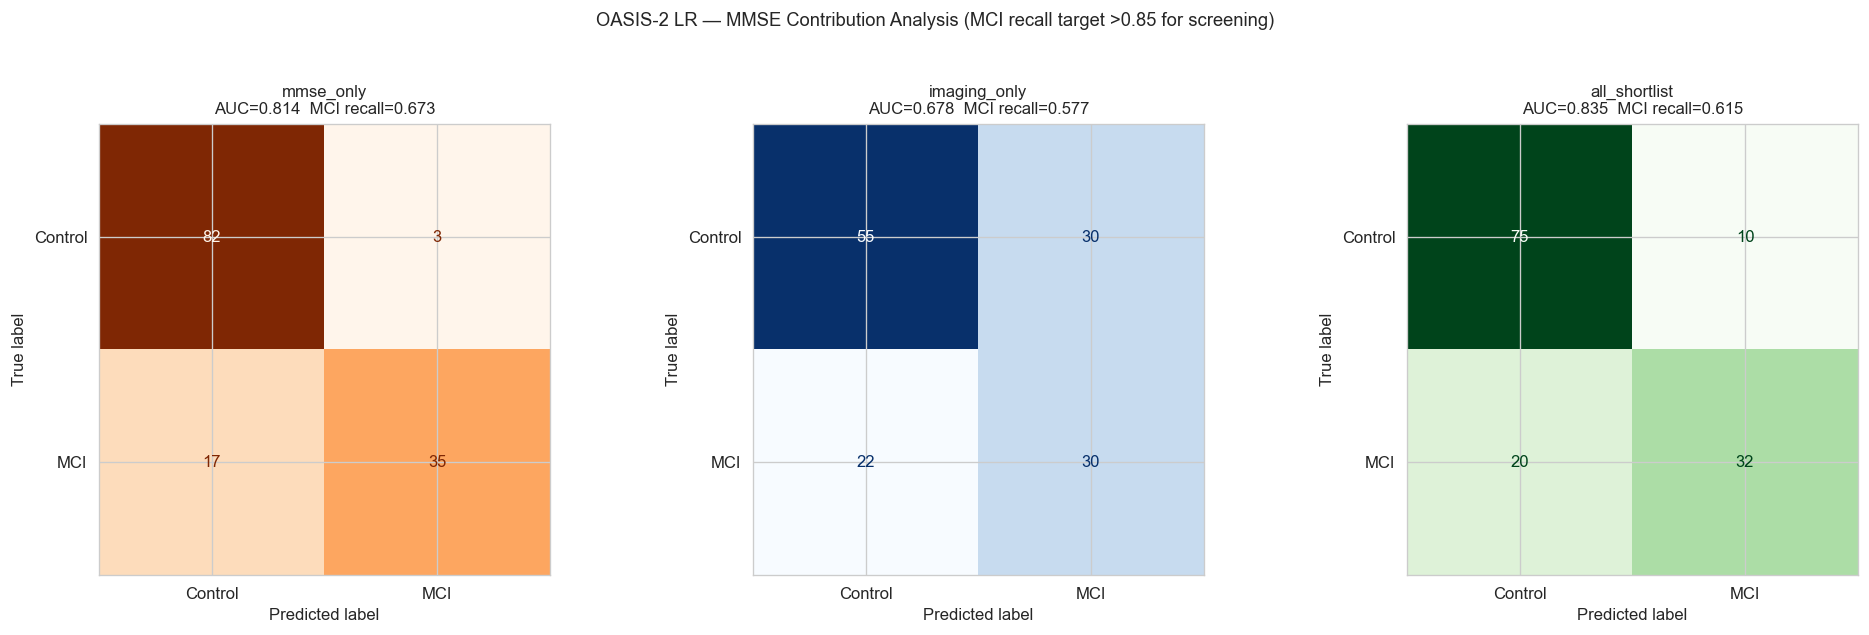

Saved → results/figures/oasis2_mmse_ablation_confmats.png


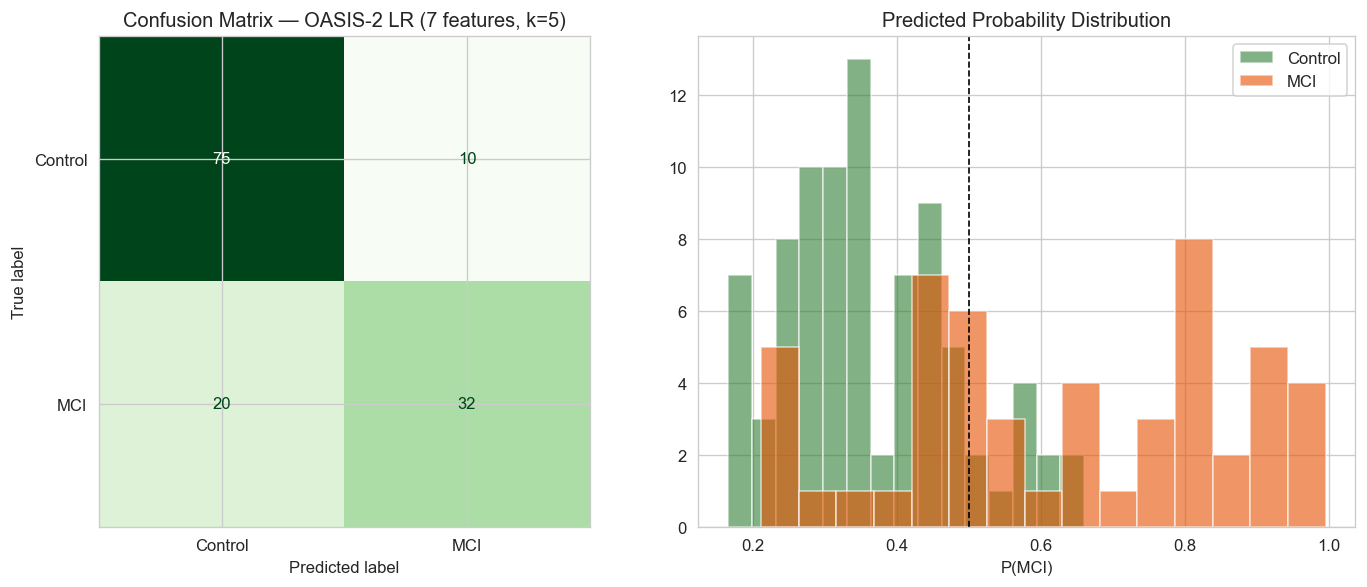

Saved → results/figures/oasis2_lr_baseline_diagnostics.png


In [14]:
# MMSE ablation confusion matrix figure + OASIS-2 LR diagnostics
plot_order = [k for k in ["mmse_only","imaging_only","all_shortlist"] if k in ablation_results]
n = len(plot_order)
fig, axes = plt.subplots(1, n, figsize=(5.5*n, 5))
axes = [axes] if n==1 else list(axes)
CMAP_MAP = {"mmse_only":"Oranges","imaging_only":"Blues","all_shortlist":"Greens","full_intensity":"Purples"}
for ax, name in zip(axes, plot_order):
    res = ablation_results[name]
    cm = confusion_matrix(res["labels"], res["preds"])
    mci_r = cm[1,1]/cm[1].sum() if cm[1].sum()>0 else 0
    auc = roc_auc_score(res["labels"], res["probs"])
    ConfusionMatrixDisplay(cm, display_labels=["Control","MCI"]).plot(
        ax=ax, colorbar=False, cmap=CMAP_MAP.get(name,"Purples"))
    ax.set_title(f"{name}\nAUC={auc:.3f}  MCI recall={mci_r:.3f}", fontsize=10)
plt.suptitle("OASIS-2 LR — MMSE Contribution Analysis (MCI recall target >0.85 for screening)",
             fontsize=11, y=1.04)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "oasis2_mmse_ablation_confmats.png", bbox_inches="tight")
plt.show()
print("Saved → results/figures/oasis2_mmse_ablation_confmats.png")

# LR baseline diagnostics figure
if "all_shortlist" in ablation_results:
    res = ablation_results["all_shortlist"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    cm = confusion_matrix(res["labels"], res["preds"])
    ConfusionMatrixDisplay(cm, display_labels=["Control","MCI"]).plot(ax=axes[0], colorbar=False, cmap="Greens")
    axes[0].set_title("Confusion Matrix — OASIS-2 LR (7 features, k=5)")
    for lv, ln, col in [(0,"Control","#2E7D32"),(1,"MCI","#E65100")]:
        axes[1].hist(res["probs"][res["labels"]==lv], bins=15, alpha=0.6, label=f"{ln}", color=col, edgecolor="white")
    axes[1].axvline(0.5,color="black",linestyle="--",linewidth=1)
    axes[1].set_xlabel("P(MCI)"); axes[1].legend()
    axes[1].set_title("Predicted Probability Distribution")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "oasis2_lr_baseline_diagnostics.png", bbox_inches="tight")
    plt.show()
    print("Saved → results/figures/oasis2_lr_baseline_diagnostics.png")

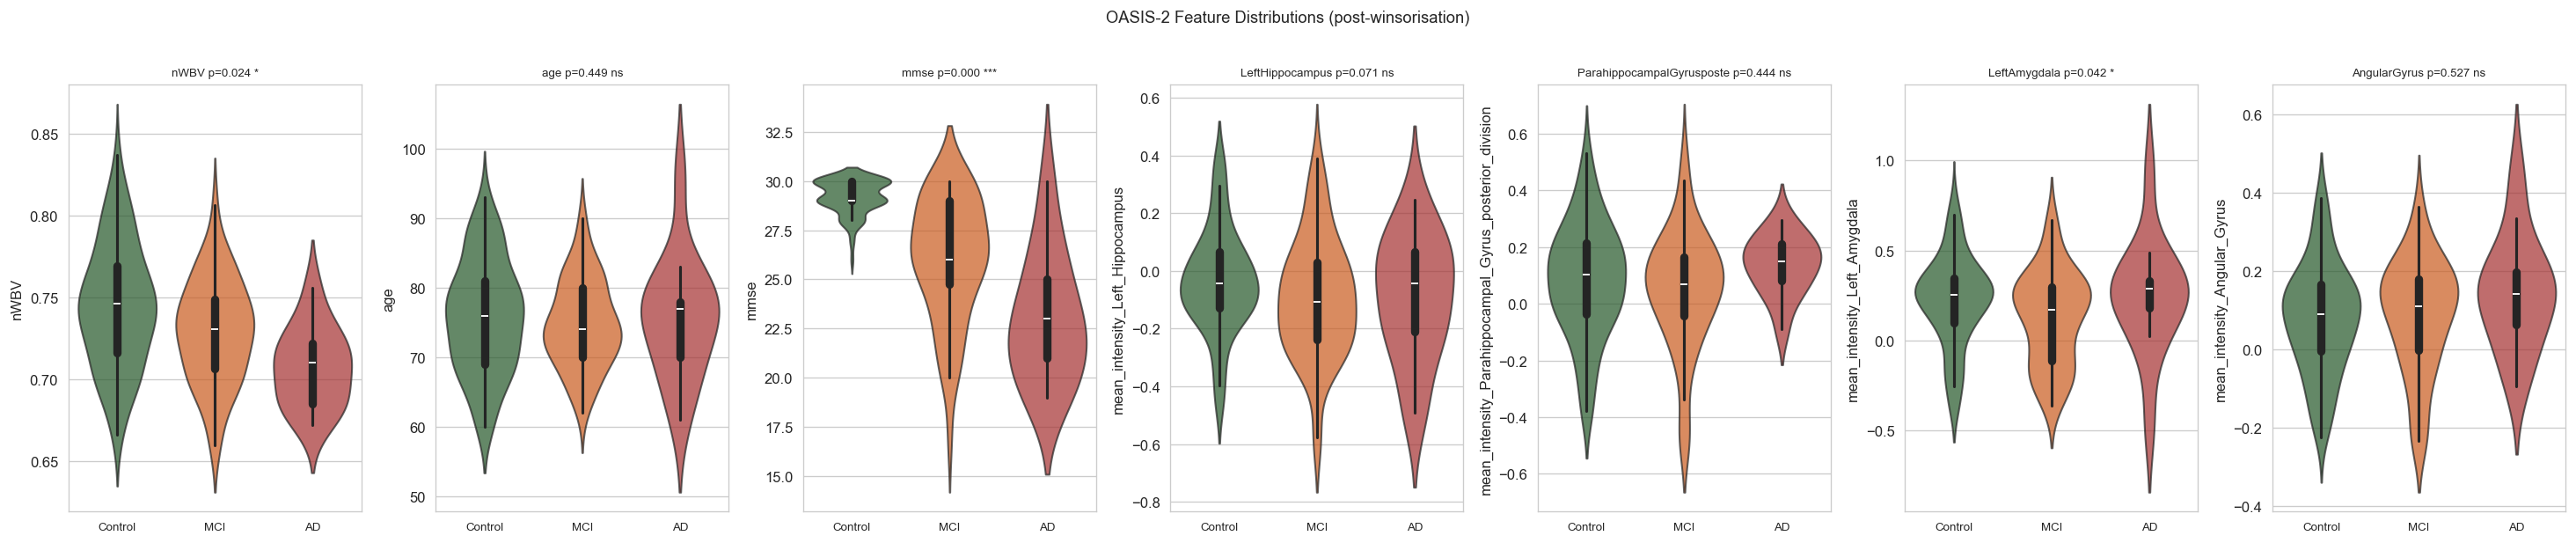

Saved → results/figures/oasis2_eda_feature_distributions.png


In [16]:
# OASIS-2 EDA — feature distributions by label
eda_feats = [c for c in available_shortlist if c in df_oasis_clean.columns]
n = len(eda_feats)
fig, axes = plt.subplots(1, n, figsize=(3.5*n, 5))
axes = [axes] if n==1 else list(axes)
PAL = {"Control":"#1B5E20","MCI":"#E65100","AD":"#B71C1C"}
for ax, feat in zip(axes, eda_feats):
    plot_df = df_oasis_clean[["label",feat]].dropna()
    order = [l for l in ["Control","MCI","AD"] if l in plot_df["label"].unique()]
    sns.violinplot(data=plot_df, x="label", y=feat, ax=ax,
                   palette=PAL, inner="box", alpha=0.7, order=order)
    c = plot_df.loc[plot_df["label"]=="Control", feat].dropna()
    m = plot_df.loc[plot_df["label"]=="MCI",     feat].dropna()
    if len(c)>1 and len(m)>1:
        _, p = mannwhitneyu(c, m, alternative="two-sided")
        sig = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "ns"))
    else: p, sig = 1.0, "ns"
    short = feat.replace("mean_intensity_","").replace("_","")[:25]
    ax.set_title(f"{short} p={p:.3f} {sig}", fontsize=8)
    ax.set_xlabel(""); ax.tick_params(axis="x", labelsize=8)

plt.suptitle("OASIS-2 Feature Distributions (post-winsorisation)", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "oasis2_eda_feature_distributions.png", bbox_inches="tight")
plt.show()
print("Saved → results/figures/oasis2_eda_feature_distributions.png")

In [17]:
# Results table summary
if results_table_path.exists():
    rt = pd.read_csv(results_table_path)
    print("="*70); print("RESULTS TABLE — LR Baselines"); print("="*70)
    print(rt[["model","dataset","n_features","macro_f1","roc_auc","mcc"]].to_string(index=False))
print("\nPreprocessing complete. Run model.ipynb next.")

RESULTS TABLE — LR Baselines
      model dataset  n_features  macro_f1  roc_auc    mcc
LR_baseline OASIS-2           7    0.7571   0.8353 0.5239

Preprocessing complete. Run model.ipynb next.
